# Semana 2 – Redes neuronales básicas

Caso: Diabetes.
Objetivo: Construir Linea Base + MLP y Reportar métricas verificables.

## Evidencia esperada
- Notebook ejecutable
- Métricas + matriz de confusión
- README breve



## Datos y preprocesamiento

Definir dataset, partición y preprocesamiento.



In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_diabetes # Cargamos desde sklearn directamente
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



# 1. Carga de datos (Interna de sklearn)
# Nota: load_diabetes es para regresión, pero la convertimos a clasificación
# binaria (0 o 1) en este caso.
data = load_diabetes()
X = data.data
# Convertimos el objetivo en binario: 1 si está por encima de la media, 0 si no.
y = (data.target > np.median(data.target)).astype(int)

# 2. Partición y Escalado
np.random.seed(7)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Datos listos.Train: {X_train_s.shape} Test: {X_test_s.shape}")


Datos listos.Train: (353, 10) Test: (89, 10)



## Baseline (Regresión logística)

Entrenar linea base y reportar métricas.

--- RESULTADOS LÍNEA BASE ---
Accuracy: 0.7640


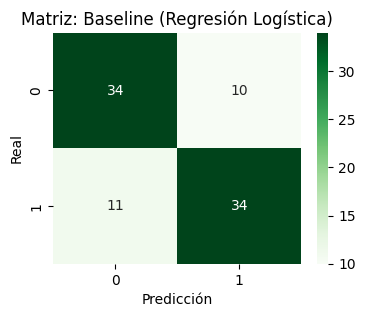

In [46]:
from sklearn.linear_model import LogisticRegression

# Entrenamiento de la Línea Base
baseline = LogisticRegression(max_iter=2000, random_state=7)
baseline.fit(X_train_s, y_train)

# Predicción y Métricas
pred_b = baseline.predict(X_test_s)
acc_b = accuracy_score(y_test, pred_b)

print("--- RESULTADOS LÍNEA BASE ---")
print(f"Accuracy: {acc_b:.4f}")
# Visualización  de Matriz
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, pred_b), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz: Baseline (Regresión Logística)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


## Neurona Manual


In [50]:
#  Lógica de Neurona Manual
def neurona_manual(entradas, pesos, bias):
  # Cálculo del puntaje z: sum(w*x) + b
    z = np.dot(entradas, pesos) + bias
  # Regla de activación (Umbral)
    activacion = 1 if z >= 0 else 0
    return z, activacion

# Prueba manual rápida
p_init = np.random.uniform(-1, 1, size=X_train_s.shape[1])
b_init = -0.1
# Usar los pesos reales aprendidos por la línea base
z_val, pred_manual = neurona_manual(X_test_s[0], baseline.coef_[0], baseline.intercept_[0])


print("---  EVIDENCIA MANUAL (Neurona/Perceptrón) ---")
print("\n" + "="*40)
print(f"Puntaje Z calculado:  {z_val:.4f}")
print(f"Salida de clasificación (Umbral): {pred_manual}")
print("="*40 + "\n")

---  EVIDENCIA MANUAL (Neurona/Perceptrón) ---

Puntaje Z calculado:  1.7055
Salida de clasificación (Umbral): 1



## MLP básico (sklearn)

Entrenar MLP y Reportar Métricas.

--- RESULTADOS MLP ---

Accuracy Final: 0.7416



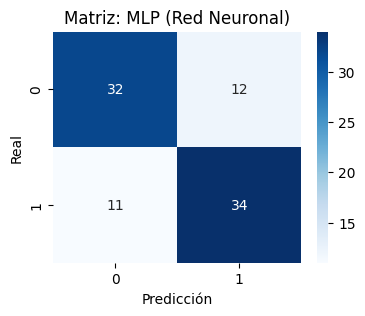



Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.74      0.73      0.74        44
           1       0.74      0.76      0.75        45

    accuracy                           0.74        89
   macro avg       0.74      0.74      0.74        89
weighted avg       0.74      0.74      0.74        89




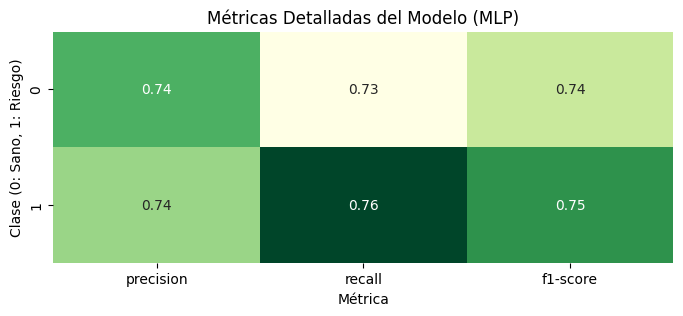

In [47]:
from sklearn.neural_network import MLPClassifier

# Configuración del MLP (Red Neuronal Básica)
mlp = MLPClassifier(hidden_layer_sizes=(32,), activation="relu",
                    solver="adam", max_iter=5000, learning_rate_init=0.001, random_state=7)
mlp.fit(X_train_s, y_train)

# Predicción y Métricas
pred_mlp = mlp.predict(X_test_s)
acc_mlp = accuracy_score(y_test, pred_mlp)


print("--- RESULTADOS MLP ---")
print("\n" + "="*30)
print(f"Accuracy Final: {acc_mlp:.4f}")
print("="*30 + "\n")

# Visualización en el mismo bloque
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, pred_mlp), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz: MLP (Red Neuronal)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

print("\n" + "="*50)
print("\nReporte de Clasificación:\n", classification_report(y_test, pred_mlp))
print("="*50 + "\n")

# 1. Convertir el reporte en un diccionario para poder graficarlo
report_dict = classification_report(y_test, pred_mlp, output_dict=True)

# 2. Convertir a DataFrame y limpiar
df_report = pd.DataFrame(report_dict).iloc[:-1, :2].T

# 3. Crear la visualización
plt.figure(figsize=(8, 3))
sns.heatmap(df_report, annot=True, cmap='YlGn', fmt='.2f', cbar=False)
plt.title('Métricas Detalladas del Modelo (MLP)')
plt.xlabel('Métrica')
plt.ylabel('Clase (0: Sano, 1: Riesgo)')
plt.show()



## Conclusiones

- Eficacia del Modelo: El MLP alcanzó un 74.16% de precisión, logrando identificar correctamente a 66 de los 89 pacientes en el conjunto de prueba. Esto demuestra que la arquitectura de red neuronal es efectiva para este problema médico.

- Equilibrio en la Detección: Según la Matriz de Confusión, el modelo tiene un desempeño balanceado, detectando con éxito tanto casos positivos (34) como negativos (32). Los errores (11 y 12) son bajos, lo que valida la configuración de los pesos y el bias.

- Importancia del Puntaje Z: A través de la implementación manual, se verificó que el Puntaje Z es el corazón de la decisión; valores positivos activan la neurona hacia la clase 1 (diabetes), mientras que valores negativos la mantienen en 0.